# **Mornington Peninsula Aridity Analysis**

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk

# Mornington Peninsula bounding box
lat_min, lat_max = -38.50, -38.05
lon_min, lon_max = 144.68, 145.35


CACHE_DIR = '/scratch/ob22/ft3359/mornington_cache'

precip_grid = xr.open_dataarray(f'{CACHE_DIR}/precip_gird_masked.nc').load()
tmax_grid = xr.open_dataarray(f'{CACHE_DIR}/tmax_grid_masked.nc').load()
tmin_grid = xr.open_dataarray(f'{CACHE_DIR}/tmin_grid_masked.nc').load()
LAND_MASK = xr.open_dataarray(f'{CACHE_DIR}/land_mask.nc').load()

print(f"Loaded cached grids: lat={precip_grid.lat.size}, lon={precip_grid.lon.size}, "
      f"time={precip_grid.time.size}")

# Spatial mean over the box
precip_box_mean = precip_grid.mean(dim=['lat', 'lon'], skipna=True)

/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)


Loaded cached grids: lat=10, lon=14, time=46021


In [2]:
def hargreaves_samani_pet(tmax, tmin, lat, doy):
    # Daily PET (mm/day)
    tmean = (tmax + tmin) / 2.0

    lat_rad = np.deg2rad(lat)
    dr = 1 + 0.033 * np.cos(2 * np.pi * doy / 365)
    delta = 0.409 * np.sin(2 * np.pi * doy / 365 - 1.39)

    ws = np.arccos(np.clip(-np.tan(lat_rad) * np.tan(lat_rad) * np.tan(delta), -1, 1))
    Ra = (24 * 60 / np.pi) * 0.0820 * dr * (
        ws * np.sin(lat_rad) * np.sin(delta)
        + np.cos(lat_rad) * np.cos(delta) * np.sin(ws)
    )

    pet = 0.0023 * (tmean + 17.8) * np.sqrt(np.maximum(tmax - tmin, 0)) * Ra
    return pet.clip(min=0)

doy = tmax_grid['time'].dt.dayofyear
lat_grid = tmax_grid['lat']

pet_daily = hargreaves_samani_pet(tmax_grid, tmin_grid, lat_grid, doy)
pet_daily = pet_daily.where(LAND_MASK)

In [3]:
# Spatial mean over the box (land-masked)
pet_annual = pet_daily.groupby('time.year').sum(dim='time')
pet_box_annual = pet_annual.mean(dim=['lat', 'lon'], skipna=True)

precip_annual = precip_grid.groupby('time.year').sum(dim='time')
map_box_annual = precip_annual.mean(dim=['lat', 'lon'], skipna=True)

n_days_per_year = precip_grid['time'].dt.year.to_series().value_counts().sort_index()
valid_years = n_days_per_year[(n_days_per_year >= 360) & (n_days_per_year.index >= 1910)].index

pet_df = pd.DataFrame({'year': pet_box_annual['year'].values, 'PET': pet_box_annual.values})
map_df = pd.DataFrame({'year': map_box_annual['year'].values, 'MAP': map_box_annual.values})

df = pd.merge(pet_df, map_df, on='year', how='inner')
df = df[df['year'].isin(valid_years)].reset_index(drop=True)
df['decade'] = (df['year'] // 10) * 10

print(f"Year range: {df['year'].min()}–{df['year'].max()}, n years: {len(df)}")
df.head()

Year range: 1910–2025, n years: 116


,year,PET,MAP,decade
0,1910,2264.712294,728.426758,1910
1,1911,2163.167376,827.934814,1910
2,1912,2237.082826,623.353821,1910
3,1913,2220.775107,675.971313,1910
4,1914,2303.551160,529.946411,1910


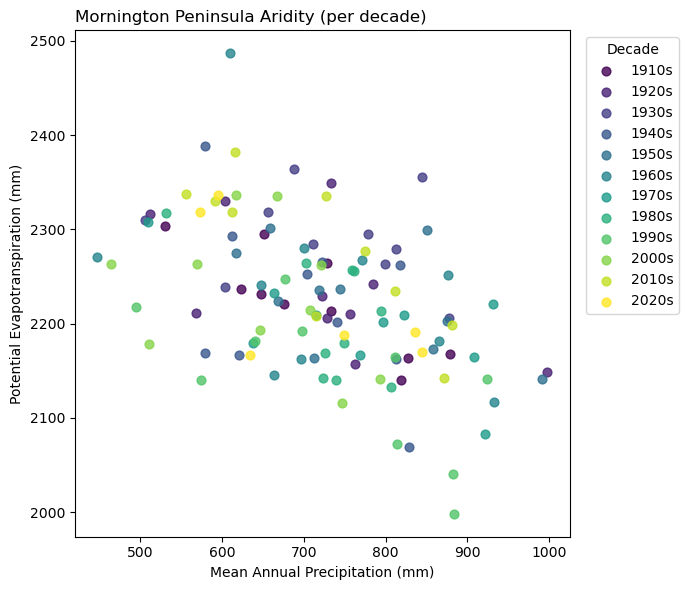

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
decades = sorted(df['decade'].unique())
cmap = plt.cm.viridis
colors = {d: cmap(i / max(len(decades) - 1, 1)) for i, d in enumerate(decades)}

for d in decades: 
    sub = df[df['decade'] == d]
    ax.scatter(sub['MAP'], sub['PET'], color=colors[d], label=f'{d}s', s=40, alpha=0.8)

ax.set_xlabel('Mean Annual Precipitation (mm)')
ax.set_ylabel('Potential Evapotranspiration (mm)')
ax.set_title('Mornington Peninsula Aridity (per decade)', loc='left')
ax.legend(title='Decade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
fig.savefig('mornington_aridity.png', dpi=300, bbox_inches='tight')
plt.show()

Saved figure


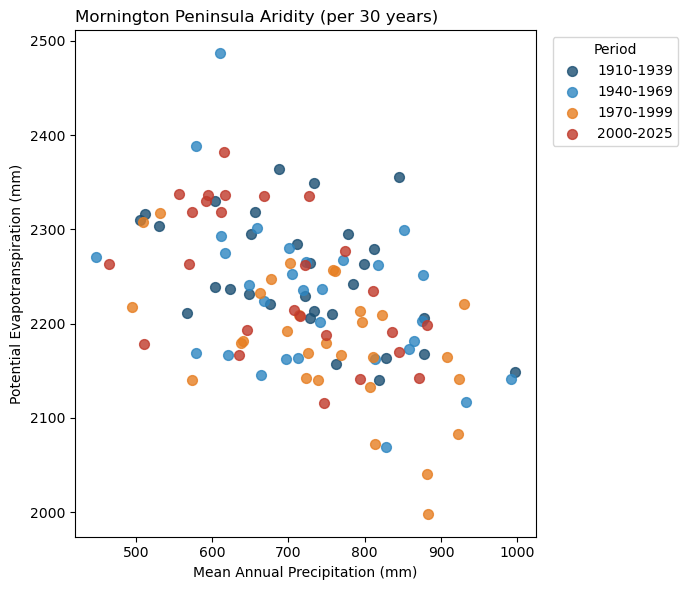

In [12]:
# 30-year period binned scatter

# Bin into 30-year periods
def assign_period(year):
    if year < 1940:
        return '1910-1939'
    elif year < 1970:
        return '1940-1969'
    elif year < 2000:
        return '1970-1999'
    else: 
        return '2000-2025'

df['period'] = df['year'].apply(assign_period)
period_order = ['1910-1939', '1940-1969', '1970-1999', '2000-2025']

fig, ax = plt.subplots(figsize=(7, 6))
period_colors = {
    '1910-1939': '#1b4f72', # Dark Blue
    '1940-1969': '#2e86c1', # Mid Blue
    '1970-1999': '#e67e22', # Orange
    '2000-2025': '#c0392b', # Red
}

for p in period_order:
    sub = df[df['period'] == p]
    ax.scatter(sub['MAP'], sub['PET'], color=period_colors[p], label=p, s=50, alpha=0.8)

ax.set_xlabel('Mean Annual Precipitation (mm)')
ax.set_ylabel('Potential Evapotranspiration (mm)')
ax.set_title('Mornington Peninsula Aridity (per 30 years)', loc='left')
ax.legend(title='Period', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
fig.savefig('mornington_aridity_30.png', dpi=300)
print(f"Saved figure")
plt.show()

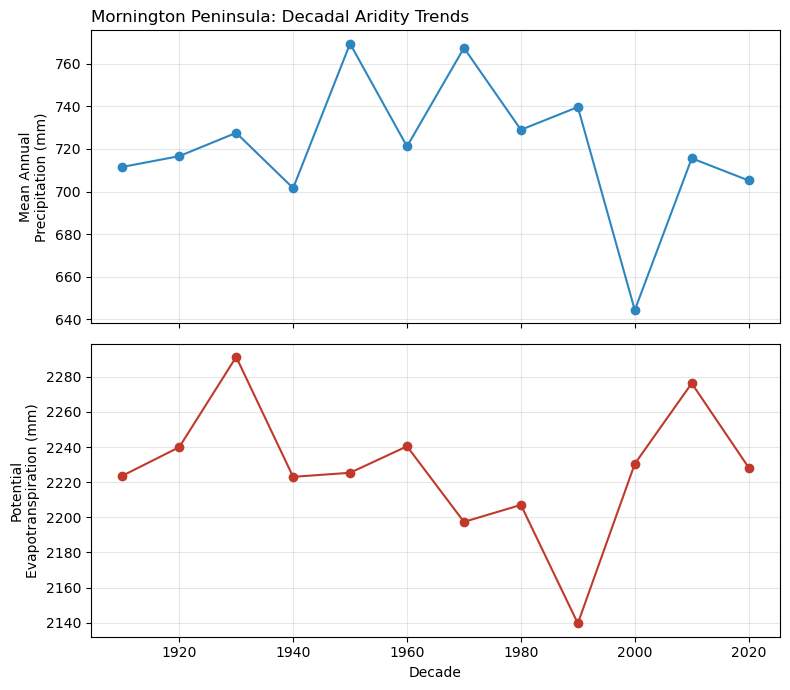

In [9]:
# Decadal Summary Panel (two time series)

# Decadal Means
decadal = df.groupby('decade').agg(PET_mean=('PET', 'mean'), MAP_mean=('MAP', 'mean')).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(decadal['decade'], decadal['MAP_mean'], marker='o', color='#2e86c1')
axes[0].set_ylabel('Mean Annual\nPrecipitation (mm)')
axes[0].set_title('Mornington Peninsula: Decadal Aridity Trends', loc='left')

axes[1].plot(decadal['decade'], decadal['PET_mean'], marker='o', color='#c0392b')
axes[1].set_ylabel('Potential\nEvapotranspiration (mm)')
axes[1].set_xlabel('Decade')

for ax in axes: 
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()